# 4 Elasticity

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.constants import *

# Load the daily aggregated data
daily_df = pd.read_csv('data/daily_aggregated_data.csv', parse_dates=['stay_date'])
daily_df.set_index('stay_date', inplace=True)
# filter dates using constants
end_date = pd.to_datetime(END_DATE) - pd.Timedelta(days=PREDICTION_HORIZON_DAYS)
start_date = pd.to_datetime(end_date) - pd.Timedelta(days=ELASTICITY_SAMPLE_DAYS)
daily_df = daily_df[(daily_df.index >= start_date) & (daily_df.index < end_date)]
daily_df = daily_df[(daily_df['occupancy_rate'] > 0) & (daily_df['avg_bed_rate'] > 0)] # ensure no zero or negative values for log transform
daily_df = daily_df.sort_index() 

# Create log-transformed columns
daily_df['log_occupancy_rate'] = np.log(daily_df['occupancy_rate'])
daily_df['log_avg_bed_rate'] = np.log(daily_df['avg_bed_rate'])

# Fit the regression model
X = sm.add_constant(daily_df['log_avg_bed_rate'])
y = daily_df['log_occupancy_rate']
model = sm.OLS(y, X).fit()
print(model.summary())

# print mean and std of the modeled coefficients
coef_mean = model.params['log_avg_bed_rate']
coef_std = model.bse['log_avg_bed_rate']
print(f"Coefficient Mean: {coef_mean:.4f}, Std Dev: {coef_std:.4f}")


                            OLS Regression Results                            
Dep. Variable:     log_occupancy_rate   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     47.43
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           7.38e-11
Time:                        22:45:39   Log-Likelihood:                -95.181
No. Observations:                 200   AIC:                             194.4
Df Residuals:                     198   BIC:                             201.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -8.5442      1.093  

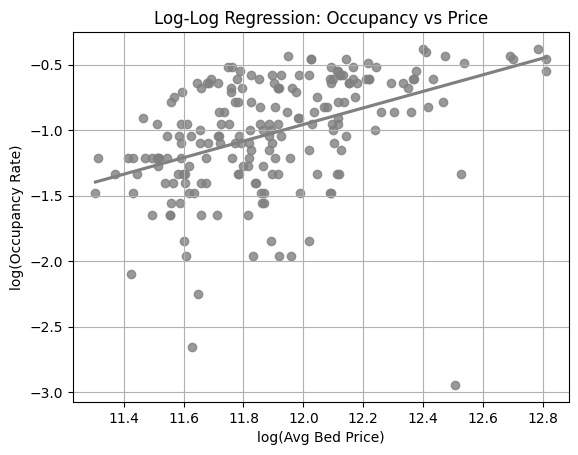

In [2]:
sns.regplot(x='log_avg_bed_rate', y='log_occupancy_rate', data=daily_df, ci=None, color='gray')
plt.title('Log-Log Regression: Occupancy vs Price')
plt.xlabel('log(Avg Bed Price)')
plt.ylabel('log(Occupancy Rate)')
plt.grid(True)
plt.show()

# Price prediction

In [65]:
from scripts.prediction import monte_carlo_revenue


demand_forecast_df = pd.read_csv('data/demand_forecasts.csv', parse_dates=['stay_date'])
listing_summary = pd.read_csv('data/listing_summary.csv')

forecast_horizon_dates = pd.date_range(start=end_date, periods=PREDICTION_HORIZON_DAYS)

def get_price_factors(listing_summary):
    min_ratio = listing_summary['min_avg_bed_rate_ratio'].min()
    max_ratio = listing_summary['max_avg_bed_rate_ratio'].max()
    price_factors = np.linspace(min_ratio, max_ratio, num=50)
    return price_factors

price_factors = get_price_factors(listing_summary)

expected_revenues = monte_carlo_revenue(
    demand_forecast_df['SARIMA_Forecast'][4],
    listing_summary['max_people_count'].sum(),
    -1.06,
    coef_std,
    price_factors,
)

# Find the alpha that gives the max expected revenue
best_index = np.argmax(expected_revenues)
best_alpha = price_factors[best_index]
best_revenue = expected_revenues[best_index]

# Result
optimal_price = best_alpha
